# Environment Setup

In [1]:
import os
import time
import json
import math
import warnings
from pathlib import Path
from copy import deepcopy
import numpy as np
import joblib
import h5py
from google.colab import drive

In [2]:
# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, LambdaLR

In [3]:
# metrics from sklearn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

In [4]:
# visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [5]:
# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : NVIDIA A100-SXM4-80GB


In [7]:
# path configuration
drive.mount('/content/drive')
# path configuration
PROJECT_ROOT = Path("/content/drive/MyDrive/SU Works/CPSC_5310_Project")
DATA_PATH    = PROJECT_ROOT / "saved_data"
MODEL_PATH   = PROJECT_ROOT / "saved_models"
OUTPUT_PATH  = DATA_PATH / "transformer_outputs"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

HDF5_PATH   = DATA_PATH / "dl_tensors" / "dl_tensors.h5"
SCALER_PATH = MODEL_PATH / "dl_feature_scaler.pkl"

assert HDF5_PATH.exists(),   f"HDF5 not found: {HDF5_PATH}"
assert SCALER_PATH.exists(), f"Scaler not found: {SCALER_PATH}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Tensors and Metadata

In [8]:
with h5py.File(HDF5_PATH, "r") as f:
    X_train = f["train/X"][:]               # float32 (N_train, 24, features)
    y_train = f["train/y"][:]               # int8    (N_train,)  classes 1–5
    c_train = f["train/cluster_id"][:].astype(np.int64)   # (N_train,)

    X_val   = f["val/X"][:]
    y_val   = f["val/y"][:]
    c_val   = f["val/cluster_id"][:].astype(np.int64)

    X_test  = f["test/X"][:]
    y_test  = f["test/y"][:]
    c_test  = f["test/cluster_id"][:].astype(np.int64)

    WINDOW_SIZE   = int(f.attrs["window_size"])      # 24
    NUM_CLUSTERS  = int(f.attrs["num_clusters"])     # 150
    FEATURE_NAMES = list(f.attrs["feature_names"])
    THRESHOLDS    = f.attrs["thresholds"]
    TRAIN_END     = f.attrs["train_end"]
    VAL_END       = f.attrs["val_end"]
    TEST_START    = f.attrs["test_start"]

NUM_FEATURES = X_train.shape[2]    # read directly from tensor — NB08 now outputs 15 features
NUM_CLASSES  = 5

print("─" * 56)
print(f"  X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}      y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}     y_test  : {y_test.shape}")
print("─" * 56)
print(f"  Window   : {WINDOW_SIZE}   Features : {NUM_FEATURES}   Clusters : {NUM_CLUSTERS}")
print(f"  Train ends : {TRAIN_END}")
print(f"  Val ends   : {VAL_END}")
print(f"  Test starts: {TEST_START}")
print("─" * 56)
print("\nFeature index mapping:")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i:2d}] {name}")

────────────────────────────────────────────────────────
  X_train : (230400, 24, 15)    y_train : (230400,)
  X_val   : (28800, 24, 15)      y_val   : (28800,)
  X_test  : (64800, 24, 15)     y_test  : (64800,)
────────────────────────────────────────────────────────
  Window   : 24   Features : 15   Clusters : 150
  Train ends : 2016-03-05 23:00:00
  Val ends   : 2016-03-13 23:00:00
  Test starts: 2016-03-14 00:00:00
────────────────────────────────────────────────────────

Feature index mapping:
  [ 0] demand_count
  [ 1] total_engaged_minutes
  [ 2] speed_mph
  [ 3] airport_trip_count
  [ 4] passenger_count
  [ 5] profit_index
  [ 6] neighbor_demand_mean
  [ 7] lat_scaled
  [ 8] lon_scaled
  [ 9] hour_sin
  [10] hour_cos
  [11] dow_sin
  [12] dow_cos
  [13] is_weekend
  [14] is_blizzard


# Dataloaders

In [9]:
def make_loader(
    X: np.ndarray,
    y: np.ndarray,
    c: np.ndarray,
    batch_size: int = 512,
    shuffle: bool = False,
) -> DataLoader:
    """
    X : (N, 24, 14)  — feature sequences
    y : (N,)         — revenue classes 1–5, shifted to 0–4 here
    c : (N,)         — cluster IDs 0–149
    """
    Xt = torch.tensor(X,   dtype=torch.float32)
    yt = torch.tensor(y-1, dtype=torch.long)       # 1–5 → 0–4
    ct = torch.tensor(c,   dtype=torch.long)
    return DataLoader(
        TensorDataset(Xt, yt, ct),
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=(DEVICE.type == "cuda"),
        num_workers=0,
    )


# Class weights
raw_weights   = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=(y_train - 1),
)
CLASS_WEIGHTS = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

print("Class weights (balanced):")
for i, w in enumerate(raw_weights):
    print(f"  Class {i+1}: {w:.4f}")

BATCH_SIZE   = 512
train_loader = make_loader(X_train, y_train, c_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   c_val,   batch_size=1024)
test_loader  = make_loader(X_test,  y_test,  c_test,  batch_size=1024)

print(f"\nBatches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Class weights (balanced):
  Class 1: 1.7043
  Class 2: 0.8952
  Class 3: 0.9120
  Class 4: 0.9093
  Class 5: 0.9091

Batches — train: 450  val: 29  test: 64


# Transformer Architecture

In [10]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al. 2017).

    Adds a non-learnable position signal to each time step.
    Registered as a buffer — moves to GPU with the model but has no gradients.

    Input / output: (batch, seq_len, d_model)
    """
    def __init__(self, d_model: int, max_len: int = 24, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe  = torch.zeros(max_len, d_model)               # (T, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()  # (T, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )                                                  # (d_model/2,)

        pe[:, 0::2] = torch.sin(pos * div)   # even dims
        pe[:, 1::2] = torch.cos(pos * div)   # odd dims

        # Shape: (1, T, d_model) — the leading 1 broadcasts over batch
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [11]:
class DeepDispatchTransformer(nn.Module):
    """
    Transformer Encoder classifier for DeepDispatch revenue-class forecasting.

    Input
    -----
    x          : (batch, seq_len=24, num_features=15)
    cluster_id : (batch,)  — integer zone ID in [0, num_clusters)

    Output
    ------
    logits     : (batch, num_classes=5)

    Forward path
    ------------
    cluster_id → Embedding → expand to (batch, 24, embed_dim)
    x || embed → (batch, 24, num_features + embed_dim)
    input_proj → (batch, 24, d_model)
    pos_enc    → (batch, 24, d_model)  [sinusoidal, fixed]
    encoder    → (batch, 24, d_model)  [self-attention × num_layers]
    [:, -1, :] → (batch, d_model)      [last time step]
    head       → (batch, num_classes)
    """

    def __init__(
        self,
        num_features: int   = 15,
        num_clusters: int   = 150,
        embed_dim:    int   = 16,
        d_model:      int   = 128,
        num_heads:    int   = 4,
        num_layers:   int   = 2,
        dropout:      float = 0.1,
        num_classes:  int   = 5,
        max_len:      int   = 24,
    ):
        super().__init__()

        assert d_model % num_heads == 0, (
            f"d_model ({d_model}) must be divisible by num_heads ({num_heads})"
        )

        # Cluster embedding
        self.cluster_embed = nn.Embedding(
            num_embeddings=num_clusters,
            embedding_dim=embed_dim,
        )

        # Input projection
        # Projects (num_features + embed_dim) to d_model.
        # Necessary because d_model must be divisible by num_heads.
        self.input_proj = nn.Sequential(
            nn.Linear(num_features + embed_dim, d_model),
            nn.LayerNorm(d_model),
        )

        # Positional encoding
        self.pos_enc = SinusoidalPositionalEncoding(
            d_model=d_model,
            max_len=max_len,
            dropout=dropout,
        )

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 4,   # standard 4× expansion
            dropout=dropout,
            activation="relu",
            batch_first=True,              # (batch, seq, feature) throughout
            norm_first=True,               # Pre-LN: more stable training
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False,    # avoids a PyTorch warning
        )

        # Classification head
        # Take the last time-step output (position T-1 = hour 23).
        # Hour 23 has attended to all 24 positions via self-attention,
        # making it the natural summary token for next-hour forecasting.
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(p=dropout),
            nn.Linear(d_model, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(
        self,
        x:          torch.Tensor,   # (B, T, F)
        cluster_id: torch.Tensor,   # (B,)
    ) -> torch.Tensor:
        B, T, _ = x.shape

        # Embed cluster → (B, embed_dim) → (B, T, embed_dim)
        emb = self.cluster_embed(cluster_id).unsqueeze(1).expand(-1, T, -1)

        # Concatenate: (B, T, F + embed_dim)
        x = torch.cat([x, emb], dim=-1)

        # Project to d_model + positional encoding: (B, T, d_model)
        x = self.input_proj(x)
        x = self.pos_enc(x)

        # Transformer encoder: (B, T, d_model)
        x = self.encoder(x)

        # Last time-step as sequence summary: (B, d_model)
        x = x[:, -1, :]

        return self.head(x)    # (B, num_classes)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Sanity check
_m = DeepDispatchTransformer(num_features=NUM_FEATURES).to(DEVICE)
_x = torch.zeros(4, 24, NUM_FEATURES, device=DEVICE)
_c = torch.zeros(4, dtype=torch.long,  device=DEVICE)
_o = _m(_x, _c)
print(f"Output shape : {_o.shape}   (expect [4, 5])")
print(f"Total params : {_m.count_parameters():,}")
del _m, _x, _c, _o

Output shape : torch.Size([4, 5])   (expect [4, 5])
Total params : 404,197


In [12]:
class OrdinalCrossEntropyLoss(nn.Module):
    """
    Ordinal-aware cross-entropy loss using Earth Mover's Distance (EMD).

    Standard CrossEntropyLoss penalises all wrong predictions equally:
    predicting class 1 when truth is 5 gets the same penalty as predicting
    class 4 when truth is 5. This is wrong for an ordinal scale.

    EMD Loss fixes this by computing the L2 distance between the predicted
    cumulative distribution and the true step-function CDF. A prediction
    that is close on the ordinal scale gets a proportionally smaller penalty.

    Class weights are applied at the sample level, preserving balanced
    training against the class imbalance in Class 1 (Quiet).
    """
    def __init__(self, class_weights: torch.Tensor, num_classes: int = 5):
        super().__init__()
        self.register_buffer('class_weights', class_weights)
        self.num_classes = num_classes

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        B, K = logits.shape
        probs    = torch.softmax(logits, dim=-1)
        pred_cdf = torch.cumsum(probs, dim=-1)                              # (B, K)
        class_idx = torch.arange(K, device=logits.device).unsqueeze(0)     # (1, K)
        true_cdf  = (class_idx >= targets.unsqueeze(1)).float()             # (B, K)
        # Mean squared CDF distance over K-1 thresholds (last col always 0)
        emd_per_sample   = ((pred_cdf[:, :-1] - true_cdf[:, :-1]) ** 2).mean(dim=-1)
        sample_weights   = self.class_weights[targets]
        return (emd_per_sample * sample_weights).sum() / sample_weights.sum()


ORDINAL_CRITERION = OrdinalCrossEntropyLoss(
    class_weights=CLASS_WEIGHTS,
    num_classes=NUM_CLASSES,
).to(DEVICE)

print("OrdinalCrossEntropyLoss (EMD) instantiated ✓")
print("  Replaces: CrossEntropyLoss + label_smoothing")
print("  Effect  : gradient penalty scales with ordinal distance between classes")


OrdinalCrossEntropyLoss (EMD) instantiated ✓
  Replaces: CrossEntropyLoss + label_smoothing
  Effect  : gradient penalty scales with ordinal distance between classes


In [13]:
@torch.no_grad()
def evaluate(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
) -> dict:
    """
    Compute the full metric suite on `loader`.
    Labels in the loader are 0-indexed; returned y_true/y_pred are 1-indexed.
    """
    model.eval()
    total_loss, all_preds, all_trues = 0.0, [], []

    for X_batch, y_batch, c_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        c_batch = c_batch.to(DEVICE)

        logits = model(X_batch, c_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)

        all_preds.append(logits.argmax(1).cpu().numpy())
        all_trues.append(y_batch.cpu().numpy())

    y_pred_0 = np.concatenate(all_preds)
    y_true_0 = np.concatenate(all_trues)
    y_pred   = y_pred_0 + 1    # restore 1-indexed
    y_true   = y_true_0 + 1

    return dict(
        loss        = total_loss / len(y_true),
        accuracy    = accuracy_score(y_true, y_pred),
        weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0),
        macro_f1    = f1_score(y_true, y_pred, average="macro",    zero_division=0),
        mae         = float(np.abs(y_pred - y_true).mean()),
        tol1        = float((np.abs(y_pred - y_true) <= 1).mean()),
        y_true      = y_true,
        y_pred      = y_pred,
    )

In [14]:
def train_model(
    model:        nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    *,
    lr:              float = 1e-3,
    weight_decay:    float = 1e-4,
    warmup_epochs:   int   = 10,
    max_epochs:      int   = 80,
    patience:        int   = 15,
    checkpoint_path: Path,
) -> dict:
    """
    Training loop with:
      - Linear LR warmup for the first `warmup_epochs` epochs
      - ReduceLROnPlateau after warmup, tracking val weighted-F1
      - Early stopping on val weighted-F1

    Why warmup matters for Transformers
    ------------------------------------
    At initialisation, attention weights are near-uniform and the model has
    no meaningful representations. If Adam starts with the full learning rate,
    it takes large steps based on noisy gradients and can permanently damage
    the attention layers before they stabilise. Warmup linearly ramps the LR
    from lr/warmup_epochs → lr over the first N epochs, giving the model time
    to build coherent representations before large updates kick in.

    This is NOT needed for LSTMs (they have recurrent inductive bias from
    epoch 1), but is standard practice for Transformers since the original
    "Attention is All You Need" paper.
    """
    criterion = ORDINAL_CRITERION   # EMD ordinal loss — shared with evaluate()
    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    #  Warmup scheduler
    # Linearly scales LR: epoch 1 → lr/warmup_epochs, epoch N → lr
    def warmup_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        return 1.0

    warmup_scheduler  = LambdaLR(optimiser, lr_lambda=warmup_lambda)

    #  Post-warmup scheduler
    # Halves LR if val weighted-F1 doesn't improve for 5 epochs
    plateau_scheduler = ReduceLROnPlateau(
        optimiser, mode="max", factor=0.5, patience=5
    )

    best_val_f1 = -np.inf
    best_state  = None
    no_improve  = 0
    history     = {k: [] for k in [
        "train_loss", "val_loss",
        "train_acc",  "val_acc",
        "val_wf1",    "lr",
    ]}

    print(f"  LR warmup : {warmup_epochs} epochs  ({lr/warmup_epochs:.2e} → {lr:.2e})")
    print(f"  Plateau   : halve LR after 5 epochs no improvement")
    print()
    print(f"{'Epoch':>5} {'TrLoss':>8} {'VaLoss':>8} "
          f"{'TrAcc':>7} {'VaAcc':>7} {'VaWF1':>7} {'LR':>9}  ")
    print("─" * 66)

    for epoch in range(1, max_epochs + 1):
        #  Train
        model.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0

        for X_batch, y_batch, c_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            c_batch = c_batch.to(DEVICE)

            optimiser.zero_grad()
            logits = model(X_batch, c_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()

            ep_loss    += loss.item() * len(y_batch)
            ep_correct += (logits.argmax(1) == y_batch).sum().item()
            ep_total   += len(y_batch)

        train_loss = ep_loss / ep_total
        train_acc  = ep_correct / ep_total

        #  Validate
        val_m      = evaluate(model, val_loader, criterion)
        current_lr = optimiser.param_groups[0]["lr"]

        # Step warmup every epoch; plateau only after warmup is done
        warmup_scheduler.step()
        if epoch >= warmup_epochs:
            plateau_scheduler.step(val_m["weighted_f1"])

        #  Early stopping
        improved = val_m["weighted_f1"] > best_val_f1 + 1e-5
        if improved:
            best_val_f1 = val_m["weighted_f1"]
            best_state  = deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            no_improve  = 0
            marker      = "✓"
        else:
            no_improve += 1
            marker      = f"({no_improve}/{patience})"

        #  Log
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_m["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_m["accuracy"])
        history["val_wf1"].append(val_m["weighted_f1"])
        history["lr"].append(current_lr)

        # Mark warmup epochs clearly in the log
        warmup_tag = " [warmup]" if epoch <= warmup_epochs else ""
        print(f"{epoch:5d} {train_loss:8.4f} {val_m['loss']:8.4f} "
              f"{train_acc:7.4f} {val_m['accuracy']:7.4f} "
              f"{val_m['weighted_f1']:7.4f} {current_lr:9.2e}  {marker}{warmup_tag}")

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    print(f"\nBest val weighted-F1: {best_val_f1:.4f}")
    return history

# Hyperparameter Experimentation

In [15]:
CONFIGS = {
    "compact":  dict(d_model=64,  num_heads=4, num_layers=2, dropout=0.1, embed_dim=8),
    "standard": dict(d_model=128, num_heads=4, num_layers=2, dropout=0.1, embed_dim=16),
    "large":    dict(d_model=256, num_heads=8, num_layers=3, dropout=0.1, embed_dim=16),
}

TRAIN_KWARGS = dict(
    lr=1e-3,
    weight_decay=1e-4,
    warmup_epochs=10,
    max_epochs=80,
    patience=15,
)

all_histories   = {}
all_val_results = {}

for cfg_name, cfg_kwargs in CONFIGS.items():
    print("\n" + "═" * 104)
    print(f"  CONFIG: {cfg_name.upper()}  |  {cfg_kwargs}")
    print("═" * 104)

    model = DeepDispatchTransformer(
        num_features=NUM_FEATURES,
        num_clusters=NUM_CLUSTERS,
        num_classes=NUM_CLASSES,
        **cfg_kwargs,
    ).to(DEVICE)
    print(f"  Parameters: {model.count_parameters():,}\n")

    ckpt_path = OUTPUT_PATH / f"transformer_{cfg_name}_best.pt"
    history   = train_model(
        model, train_loader, val_loader,
        checkpoint_path=ckpt_path,
        **TRAIN_KWARGS,
    )
    all_histories[cfg_name] = history

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    val_res = evaluate(model, val_loader, ORDINAL_CRITERION)
    all_val_results[cfg_name] = val_res

    print(f"\n  Val → Acc: {val_res['accuracy']:.4f}  "
          f"WF1: {val_res['weighted_f1']:.4f}  "
          f"MF1: {val_res['macro_f1']:.4f}  "
          f"MAE: {val_res['mae']:.4f}")


════════════════════════════════════════════════════════════════════════════════════════════════════════
  CONFIG: COMPACT  |  {'d_model': 64, 'num_heads': 4, 'num_layers': 2, 'dropout': 0.1, 'embed_dim': 8}
════════════════════════════════════════════════════════════════════════════════════════════════════════
  Parameters: 103,285

  LR warmup : 10 epochs  (1.00e-04 → 1.00e-03)
  Plateau   : halve LR after 5 epochs no improvement

Epoch   TrLoss   VaLoss   TrAcc   VaAcc   VaWF1        LR  
──────────────────────────────────────────────────────────────────
    1   0.1051   0.0736  0.4702  0.6196  0.6115  1.00e-04  ✓ [warmup]
    2   0.0629   0.0591  0.6495  0.7027  0.7005  2.00e-04  ✓ [warmup]
    3   0.0539   0.0554  0.7024  0.7279  0.7266  3.00e-04  ✓ [warmup]
    4   0.0502   0.0538  0.7229  0.7376  0.7377  4.00e-04  ✓ [warmup]
    5   0.0479   0.0526  0.7357  0.7469  0.7460  5.00e-04  ✓ [warmup]
    6   0.0464   0.0517  0.7443  0.7480  0.7478  6.00e-04  ✓ [warmup]
    7   0.0451 

In [15]:
# Select best config by validation weighted-F1
BEST_CFG = max(all_val_results, key=lambda k: all_val_results[k]["weighted_f1"])
print(f"Best configuration : '{BEST_CFG}'")
print(f"  Val Acc    : {all_val_results[BEST_CFG]['accuracy']:.4f}")
print(f"  Val Wt. F1 : {all_val_results[BEST_CFG]['weighted_f1']:.4f}")

best_model = DeepDispatchTransformer(
    num_features=NUM_FEATURES,
    num_clusters=NUM_CLUSTERS,
    num_classes=NUM_CLASSES,
    **CONFIGS[BEST_CFG],
).to(DEVICE)
best_model.load_state_dict(
    torch.load(OUTPUT_PATH / f"transformer_{BEST_CFG}_best.pt", map_location=DEVICE)
)
best_model.eval()
print("Best model loaded")

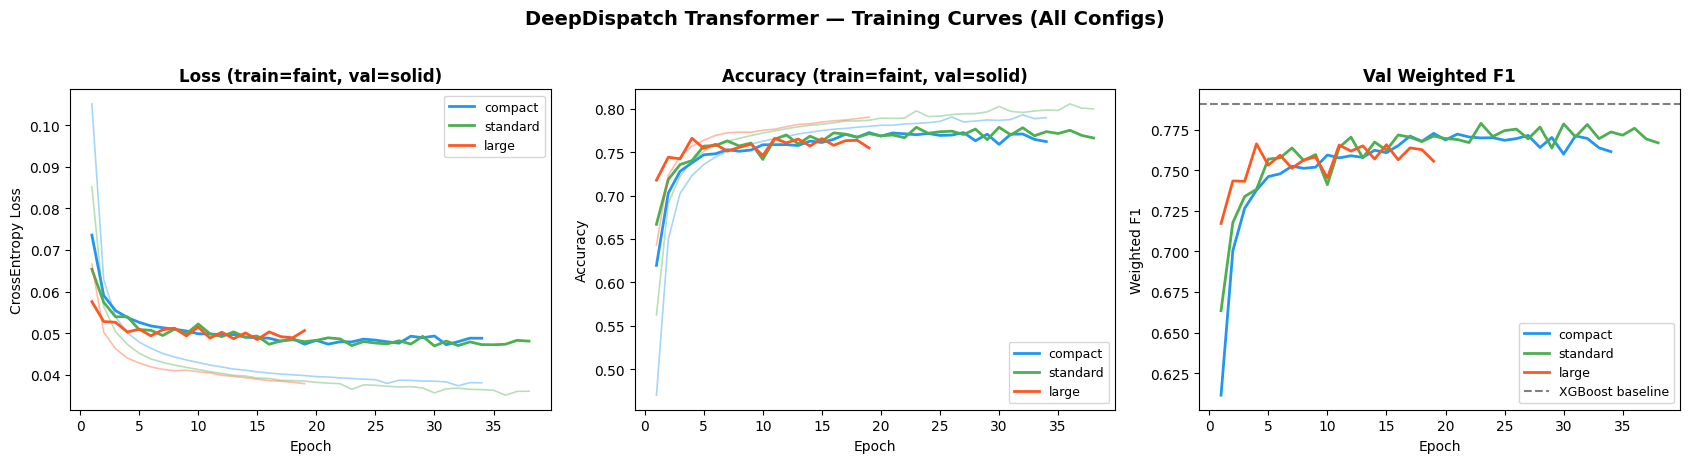

In [16]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
palette   = {"compact": "#2196F3", "standard": "#4CAF50", "large": "#FF5722"}

for cfg_name, hist in all_histories.items():
    color = palette[cfg_name]
    ep    = range(1, len(hist["val_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"], color=color, lw=1.2, alpha=0.4)
    axes[0].plot(ep, hist["val_loss"],   color=color, lw=2,   label=cfg_name)
    axes[1].plot(ep, hist["train_acc"],  color=color, lw=1.2, alpha=0.4)
    axes[1].plot(ep, hist["val_acc"],    color=color, lw=2,   label=cfg_name)
    axes[2].plot(ep, hist["val_wf1"],    color=color, lw=2,   label=cfg_name)

axes[2].axhline(0.7908, color="gray", ls="--", lw=1.5, label="XGBoost baseline")

for ax, title, ylabel in zip(
    axes,
    ["Loss (train=faint, val=solid)", "Accuracy (train=faint, val=solid)", "Val Weighted F1"],
    ["CrossEntropy Loss", "Accuracy", "Weighted F1"],
):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

fig.suptitle("DeepDispatch Transformer — Training Curves (All Configs)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "training_curves.png", bbox_inches="tight")
plt.show()

In [18]:
# Select best config by validation weighted-F1
BEST_CFG = max(all_val_results, key=lambda k: all_val_results[k]["weighted_f1"])
print(f"Best configuration : '{BEST_CFG}'")
print(f"  Val Acc    : {all_val_results[BEST_CFG]['accuracy']:.4f}")
print(f"  Val Wt. F1 : {all_val_results[BEST_CFG]['weighted_f1']:.4f}")

best_model = DeepDispatchTransformer(
    num_features=NUM_FEATURES,
    num_clusters=NUM_CLUSTERS,
    num_classes=NUM_CLASSES,
    **CONFIGS[BEST_CFG],
).to(DEVICE)
best_model.load_state_dict(
    torch.load(OUTPUT_PATH / f"transformer_{BEST_CFG}_best.pt", map_location=DEVICE)
)
best_model.eval()
print("Best model loaded")

Best configuration : 'standard'
  Val Acc    : 0.7785
  Val Wt. F1 : 0.7788
Best model loaded


In [19]:
test_metrics = evaluate(best_model, test_loader, ORDINAL_CRITERION)

print("\n" + "═" * 54)
print("  FINAL TEST RESULTS — DeepDispatch Transformer")
print("═" * 54)
print(f"  Config          : {BEST_CFG}")
print(f"  Test Accuracy   : {test_metrics['accuracy']*100:.2f}%")
print(f"  Weighted F1     : {test_metrics['weighted_f1']:.4f}")
print(f"  Macro F1        : {test_metrics['macro_f1']:.4f}")
print(f"  MAE (ordinal)   : {test_metrics['mae']:.4f}")
print(f"  1-class Tol.    : {test_metrics['tol1']*100:.2f}%")
print("─" * 54)
print("  XGBoost baseline: Acc=79.12%  WF1=0.7908  MAE=0.2119")
print("═" * 54)

delta_acc = test_metrics['accuracy'] - 0.7912
delta_wf1 = test_metrics['weighted_f1'] - 0.7908
print(f"\n  Δ vs XGBoost → Acc: {delta_acc*100:+.2f}pp  WF1: {delta_wf1:+.4f}")


══════════════════════════════════════════════════════
  FINAL TEST RESULTS — DeepDispatch Transformer
══════════════════════════════════════════════════════
  Config          : standard
  Test Accuracy   : 78.22%
  Weighted F1     : 0.7824
  Macro F1        : 0.7798
  MAE (ordinal)   : 0.2285
  1-class Tol.    : 99.32%
──────────────────────────────────────────────────────
  XGBoost baseline: Acc=79.12%  WF1=0.7908  MAE=0.2119
══════════════════════════════════════════════════════

  Δ vs XGBoost → Acc: -0.90pp  WF1: -0.0084


# Error Analysis

In [20]:
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]
CLASS_LABELS = ["1: Quiet", "2: Steady", "3: Busy", "4: High Value", "5: Surge"]

print(classification_report(y_true, y_pred, target_names=CLASS_LABELS, digits=4))

               precision    recall  f1-score   support

     1: Quiet     0.7007    0.8559    0.7706      6502
    2: Steady     0.7757    0.7296    0.7519     13845
      3: Busy     0.7518    0.7219    0.7365     14690
4: High Value     0.7446    0.7677    0.7560     14464
     5: Surge     0.8981    0.8700    0.8838     15299

     accuracy                         0.7822     64800
    macro avg     0.7742    0.7890    0.7798     64800
 weighted avg     0.7847    0.7822    0.7824     64800



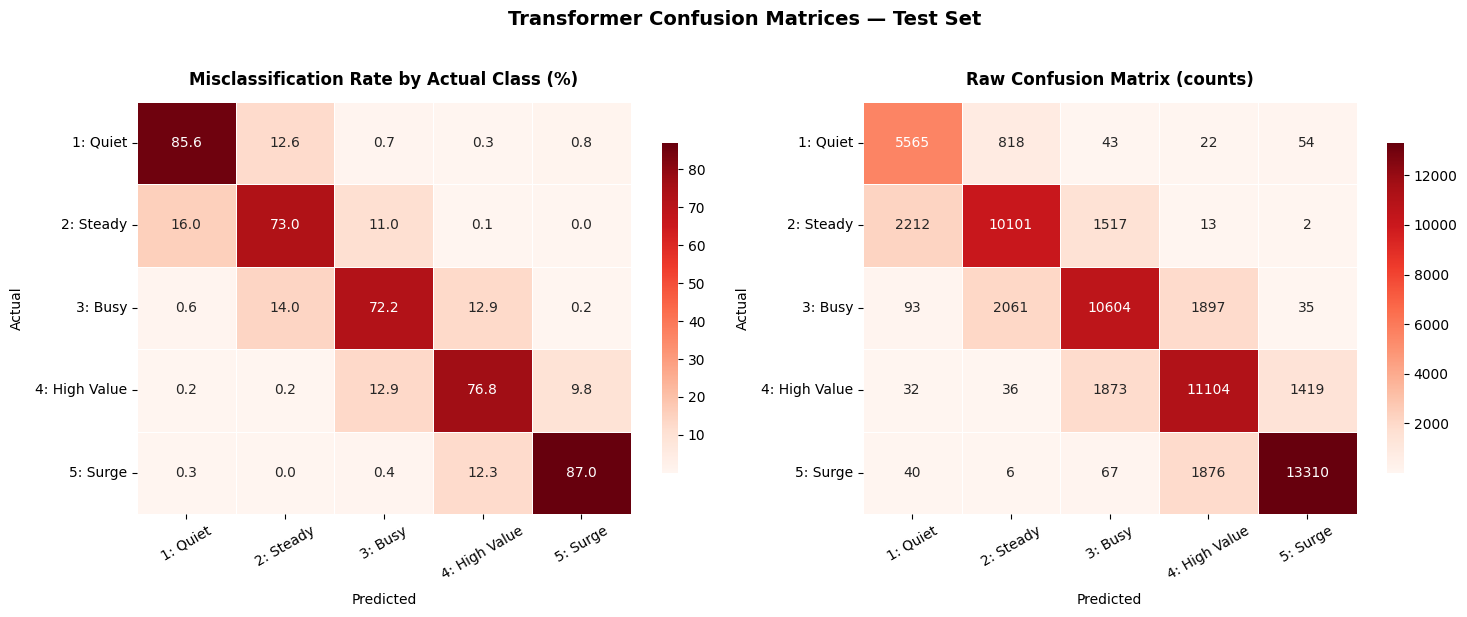

In [21]:
# Confusion matrices
cm_raw  = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cm, fmt, title in zip(
    axes,
    [cm_norm * 100, cm_raw],
    [".1f", "d"],
    ["Misclassification Rate by Actual Class (%)", "Raw Confusion Matrix (counts)"],
):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Reds",
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                linewidths=0.5, linecolor="white", ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted", labelpad=8)
    ax.set_ylabel("Actual",    labelpad=8)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Transformer Confusion Matrices — Test Set",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "confusion_matrix.png", bbox_inches="tight")
plt.show()

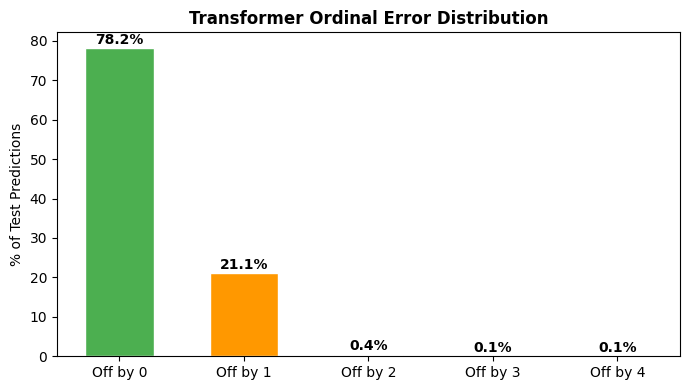

In [22]:
# Ordinal error distribution
errors     = np.abs(y_pred - y_true)
error_dist = {int(e): float((errors == e).mean() * 100)
              for e in sorted(np.unique(errors))}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    list(error_dist.keys()),
    list(error_dist.values()),
    color=["#4CAF50" if k == 0 else "#FF9800" if k == 1 else "#F44336"
           for k in error_dist],
    edgecolor="white", width=0.55,
)
for bar, pct in zip(bars, error_dist.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")

ax.set_xticks(list(error_dist.keys()))
ax.set_xticklabels([f"Off by {k}" for k in error_dist.keys()])
ax.set_ylabel("% of Test Predictions")
ax.set_title("Transformer Ordinal Error Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "ordinal_error_distribution.png", bbox_inches="tight")
plt.show()

In [24]:
# Load LSTM results
lstm_acc  = 0.7844
lstm_wf1  = 0.7849
lstm_mf1  = 0.7824
lstm_mae  = 0.2260
lstm_tol1 = 0.9932
lstm_cfg  = "LSTM (standard)"

# Build comparison DataFrame
import pandas as pd # Adding this to ensure pandas is imported

rows = [
    {
        "Model":     "Naive Baseline (Cluster+Hour)",
        "Accuracy":  "68.91%",
        "Wt. F1":   "0.6900",
        "Macro F1": "0.6900",
        "MAE":      "—",
        "1-cls Tol": "—",
    },
    {
        "Model":     "Logistic Regression",
        "Accuracy":  "75.36%",
        "Wt. F1":   "0.7522",
        "Macro F1": "0.7500",
        "MAE":      "0.2513",
        "1-cls Tol": "—",
    },
    {
        "Model":     "Random Forest",
        "Accuracy":  "78.41%",
        "Wt. F1":   "0.7838",
        "Macro F1": "0.7800",
        "MAE":      "0.2194",
        "1-cls Tol": "—",
    },
    {
        "Model":     "XGBoost (Tuned)",
        "Accuracy":  "79.12%",
        "Wt. F1":   "0.7908",
        "Macro F1": "0.7900",
        "MAE":      "0.2119",
        "1-cls Tol": "99.74%",
    },
    {
        "Model":     f"{lstm_cfg}", # Updated to reflect user's table
        "Accuracy":  f"{lstm_acc*100:.2f}%",
        "Wt. F1":   f"{lstm_wf1:.4f}",
        "Macro F1": f"{lstm_mf1:.4f}",
        "MAE":      f"{lstm_mae:.4f}",
        "1-cls Tol": f"{lstm_tol1*100:.2f}%",
    },
    {
        "Model":     f"Transformer ({BEST_CFG})",
        "Accuracy":  f"{test_metrics['accuracy']*100:.2f}%",
        "Wt. F1":   f"{test_metrics['weighted_f1']:.4f}",
        "Macro F1": f"{test_metrics['macro_f1']:.4f}",
        "MAE":      f"{test_metrics['mae']:.4f}",
        "1-cls Tol": f"{test_metrics['tol1']*100:.2f}%",
    },
]

df = pd.DataFrame(rows).set_index("Model")
print("\n" + "═" * 72)
print("  FULL DEEPDISPATCH MODEL COMPARISON")
print("═" * 72)
print(df.to_string())
print("═" * 72)

df.to_csv(OUTPUT_PATH / "full_model_comparison.csv")
print(f"\nSaved: {OUTPUT_PATH / 'full_model_comparison.csv'}")


════════════════════════════════════════════════════════════════════════
  FULL DEEPDISPATCH MODEL COMPARISON
════════════════════════════════════════════════════════════════════════
                              Accuracy  Wt. F1 Macro F1     MAE 1-cls Tol
Model                                                                    
Naive Baseline (Cluster+Hour)   68.91%  0.6900   0.6900       —         —
Logistic Regression             75.36%  0.7522   0.7500  0.2513         —
Random Forest                   78.41%  0.7838   0.7800  0.2194         —
XGBoost (Tuned)                 79.12%  0.7908   0.7900  0.2119    99.74%
LSTM (standard)                 78.44%  0.7849   0.7824  0.2260    99.32%
Transformer (standard)          78.22%  0.7824   0.7798  0.2285    99.32%
════════════════════════════════════════════════════════════════════════

Saved: /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/transformer_outputs/full_model_comparison.csv


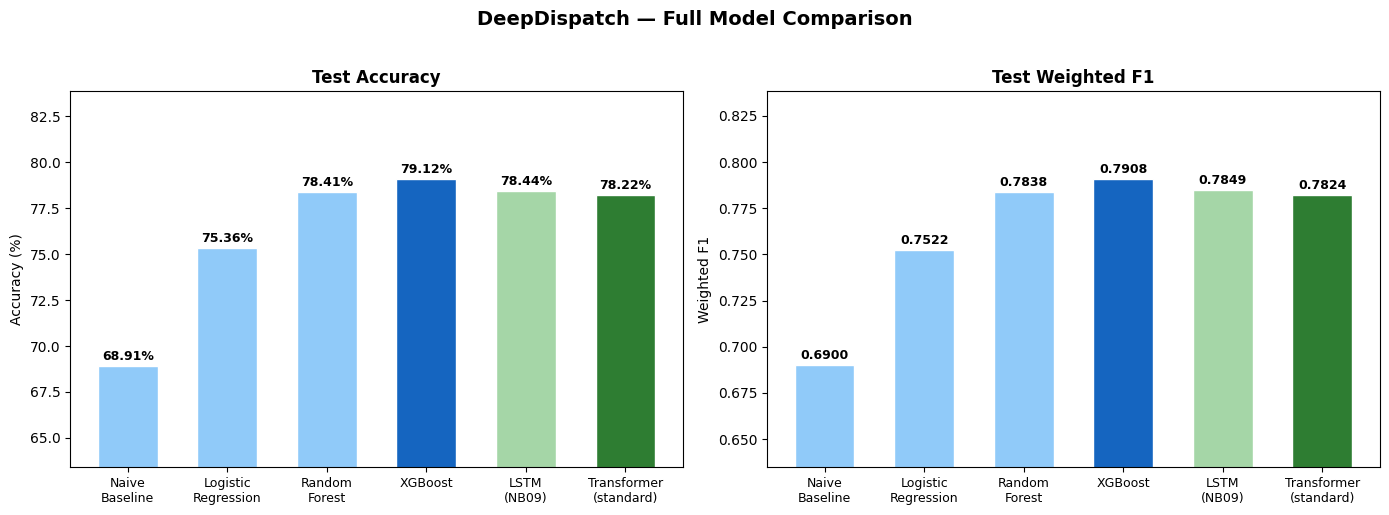

In [25]:
# Visual comparison: Accuracy & Weighted F1 bar chart
model_names = [
    "Naive\nBaseline",
    "Logistic\nRegression",
    "Random\nForest",
    "XGBoost",
    f"LSTM\n({lstm_cfg.split('-')[-1] if '-' in lstm_cfg else 'NB09'})",
    f"Transformer\n({BEST_CFG})",
]
accuracies = [
    68.91, 75.36, 78.41, 79.12,
    lstm_acc * 100,
    test_metrics['accuracy'] * 100,
]
wf1_scores = [
    0.6900, 0.7522, 0.7838, 0.7908,
    lstm_wf1,
    test_metrics['weighted_f1'],
]
colors = ["#90CAF9", "#90CAF9", "#90CAF9", "#1565C0",
          "#A5D6A7", "#2E7D32"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, ylabel, title, fmt in zip(
    axes,
    [accuracies, wf1_scores],
    ["Accuracy (%)", "Weighted F1"],
    ["Test Accuracy", "Test Weighted F1"],
    ["{:.2f}%", "{:.4f}"],
):
    bars = ax.bar(model_names, values, color=colors,
                  edgecolor="white", width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002 * max(values),
                fmt.format(val),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(values) * 0.92, max(values) * 1.06)
    ax.tick_params(axis="x", labelsize=9)

fig.suptitle("DeepDispatch — Full Model Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "full_model_comparison_chart.png", bbox_inches="tight")
plt.show()

In [26]:
# Save final model
FINAL_MODEL_PATH = MODEL_PATH / "transformer_final.pt"
torch.save({
    "model_state_dict": best_model.state_dict(),
    "config":           CONFIGS[BEST_CFG],
    "best_config_name": BEST_CFG,
    "num_features":     NUM_FEATURES,
    "num_clusters":     NUM_CLUSTERS,
    "num_classes":      NUM_CLASSES,
    "feature_names":    FEATURE_NAMES,
    "window_size":      WINDOW_SIZE,
    "test_metrics": {
        k: v for k, v in test_metrics.items()
        if k not in ("y_true", "y_pred")
    },
}, FINAL_MODEL_PATH)

# Save metrics JSON
metrics_out = {
    "model":          f"Transformer-{BEST_CFG}",
    "config":         CONFIGS[BEST_CFG],
    "test_accuracy":  round(float(test_metrics["accuracy"]),     4),
    "weighted_f1":    round(float(test_metrics["weighted_f1"]),  4),
    "macro_f1":       round(float(test_metrics["macro_f1"]),     4),
    "mae_ordinal":    round(float(test_metrics["mae"]),          4),
    "tol1_accuracy": round(float(test_metrics["tol1"]),         4),
    "xgboost_baseline": {"accuracy": 0.7912, "weighted_f1": 0.7908, "mae": 0.2119},
}
with open(OUTPUT_PATH / "transformer_test_metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

#  Summary
print("═" * 54)
print(f"  Best config  : {BEST_CFG}")
print(f"  Test Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"  Weighted F1  : {test_metrics['weighted_f1']:.4f}")
print(f"  MAE (ordinal): {test_metrics['mae']:.4f}")
print(f"  1-class tol  : {test_metrics['tol1']*100:.2f}%")
print("─" * 54)
print("  Artifacts saved to:", OUTPUT_PATH)
print("  ├─ transformer_final.pt")
print("  ├─ transformer_test_metrics.json")
print("  ├─ full_model_comparison.csv")
print("  ├─ full_model_comparison_chart.png")
print("  ├─ training_curves.png")
print("  ├─ confusion_matrix.png")
print("  └─ ordinal_error_distribution.png")
print("═" * 54)

══════════════════════════════════════════════════════
  Best config  : standard
  Test Accuracy: 78.22%
  Weighted F1  : 0.7824
  MAE (ordinal): 0.2285
  1-class tol  : 99.32%
──────────────────────────────────────────────────────
  Artifacts saved to: /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/transformer_outputs
  ├─ transformer_final.pt
  ├─ transformer_test_metrics.json
  ├─ full_model_comparison.csv
  ├─ full_model_comparison_chart.png
  ├─ training_curves.png
  ├─ confusion_matrix.png
  └─ ordinal_error_distribution.png
══════════════════════════════════════════════════════
